### Function to fix peak/valley bug (not succesfull yet)

In [ ]:
import numpy as np

def _coerce_peak_valley_indices(hf_obj):
    # Some versions store peaks/valleys as float arrays → force to int indices
    for attr in ("peaks", "valleys"):
        if hasattr(hf_obj, attr):
            arr = np.asarray(getattr(hf_obj, attr))
            # round → int; if already int, this is a no-op
            if arr.size and not np.issubdtype(arr.dtype, np.integer):
                setattr(hf_obj, attr, np.rint(arr).astype(int))


## Ectract handwriting features and store them to csv

In [ ]:

import os
from pathlib import Path
import pandas as pd
from handwriting_features import HandwritingFeatures as hf

directory_path = "C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002"

pathlist = Path(directory_path).rglob("*.svc")

variables = ["y", "x", "time", "pen_status", "azimuth", "tilt", "pressure"]
pd_rows = []
fs = 133  # Sampling frequency in Hz
i = 0

def diagnosis_from_filename(filename):
    if filename.startswith("HC"):
        return 1
    elif filename.startswith("pre-LBD"):
        return 0
    else:
        return None  # or raise an exception if appropriate
for path in pathlist:
    feature_data = hf.from_svc(str(path), variables)
    _coerce_peak_valley_indices(feature_data)
    diagnosis = diagnosis_from_filename(path.name)
    # Extract features

    ## kinematic features
    x_velocity_loop = feature_data.velocity(axis="x", in_air=False, statistics=["mean", "std"])
    y_velocity_loop = feature_data.velocity(axis="y", in_air=False, statistics=["mean", "std"])

    x_velocity_loop = feature_data.velocity(axis="x", in_air=False, statistics=["mean", "std"])
    y_velocity_loop = feature_data.velocity(axis="y", in_air=False, statistics=["mean", "std"])

    xy_jerk_loop = feature_data.jerk(axis="xy", in_air=False, statistics=["mean", "std"])

    # Dynamic features
    azimuth_loop = feature_data.azimuth(in_air=False, statistics=["mean", "std"])
    tilt_loop = feature_data.tilt(statistics=["mean", "std"])
    pressure_loop = feature_data.pressure(statistics=["mean", "std"])
    
    # Spatial features
    stroke_length_loop = feature_data.stroke_length(in_air=False, statistics=["mean", "std"])
    stroke_height_loop = feature_data.stroke_height(in_air=False, statistics=["mean", "std"])
    stroke_width_loop = feature_data.stroke_width(in_air=False, statistics=["mean", "std"])

    writing_length_loop = feature_data.writing_length(in_air=False)
    writing_height_loop = feature_data.writing_height(in_air=False)
    writing_width_loop = feature_data.writing_width(in_air=False)

    nisi_itra_loop = feature_data.number_of_intra_stroke_intersections(statistics=["mean", "std"])
    relatigve_nisi_itra_loop = feature_data.relative_number_of_intra_stroke_intersections(statistics=["mean", "std"])
    total_nisi_itra_loop = feature_data.total_number_of_intra_stroke_intersections()
    relative_total_nisi_itra_loop = feature_data.relative_total_number_of_intra_stroke_intersections()

    nisi_inter_loop = feature_data.number_of_inter_stroke_intersections()
    relatigve_nisi_inter_loop = feature_data.relative_number_of_inter_stroke_intersections()

    #vertical_peaks_indices_loop = feature_data.vertical_peaks_indices(fs=fs, statistics=["mean", "std"])
    #vertical_valeys_indices_loop = feature_data.vertical_valleys_indices(fs=fs, statistics=["mean", "std"])
    #vertical_peaks_values_loop = feature_data.vertical_peaks_values(fs=fs, statistics=["mean", "std"])
    #vertical_valeys_values_loop = feature_data.vertical_valleys_values(fs=fs, statistics=["mean", "std"])
    #vertical_peaks_velocity_loop = feature_data.vertical_peaks_velocity(fs=fs, statistics=["mean", "std"])
    #vertical_valeys_velocity_loop = feature_data.vertical_valleys_velocity(fs=fs, statistics=["mean", "std"])
    #vertical_peaks_distance_loop = feature_data.vertical_peaks_distance(fs=fs, statistics=["mean", "std"])
    #vertical_valeys_distance_loop = feature_data.vertical_valleys_distance(fs=fs, statistics=["mean", "std"])
    #vertical_peaks_duration_loop = feature_data.vertical_peaks_duration(fs=fs, statistics=["mean", "std"])
    #vertical_valeys_duration_loop = feature_data.vertical_valleys_duration(fs=fs, statistics=["mean", "std"])

    ## Temporal features
    stroke_duration_loop = feature_data.stroke_duration(in_air=False, statistics=["mean", "std"])
    ratio_of_stroke_durations_loop = feature_data.ratio_of_stroke_durations(statistics=["mean", "std"])
    writing_duration_loop = feature_data.writing_duration(in_air=False)
    writing_duration_overall_loop = feature_data.writing_duration_overall()
    ratio_of_writing_duration_loop = feature_data.ratio_of_writing_durations()
    number_of_interruptions_loop = feature_data.number_of_interruptions()
    number_of_interruptions_relative_loop = feature_data.number_of_interruptions_relative()
    
    # Composite features
    #writing_tempo_loop = feature_data.writing_tempo(in_air=False)
    #writing_stops_loop = feature_data.writing_stops()

    #number_of_changes_in_profile_x_loop = feature_data.number_of_changes_in_x_profile(fs=fs)
    #number_of_changes_in_profile_y_loop = feature_data.number_of_changes_in_y_profile(fs=fs)
    #number_of_changes_in_azimuth_loop = feature_data.number_of_changes_in_azimuth(fs=fs, n = 5)
    #number_of_changes_in_tilt_loop = feature_data.number_of_changes_in_tilt(fs=fs, n = 5)
    #number_of_changes_in_pressure_loop = feature_data.number_of_changes_in_pressure(fs=fs)
    #number_of_changes_in_velocity_profile_loop = feature_data.number_of_changes_in_velocity_profile(fs=fs)

    pandas_row = {
        "file_name": path.name,
        "diagnosis": diagnosis,
        "x_velocity_mean" : x_velocity_loop[0],
        "x_velocity_std" : x_velocity_loop[1],
        "y_velocity_mean" : y_velocity_loop[0],
        "y_velocity_std" : y_velocity_loop[1],
        "xy_jerk_mean" : xy_jerk_loop[0],
        "xy_jerk_std" : xy_jerk_loop[1],
        "azimuth_mean" : azimuth_loop[0],
        "azimuth_std" : azimuth_loop[1],
        "tilt_mean" : tilt_loop[0],
        "tilt_std" : tilt_loop[1],
        "pressure_mean" : pressure_loop[0],
        "pressure_std" : pressure_loop[1],
        "stroke_length_mean" : stroke_length_loop[0],
        "stroke_length_std" : stroke_length_loop[1],
        "stroke_height_mean" : stroke_height_loop[0],
        "stroke_height_std" : stroke_height_loop[1],
        "stroke_width_mean" : stroke_width_loop[0],
        "stroke_width_std" : stroke_width_loop[1],   
        "writing_length" : writing_length_loop[0],
        "writing_height" : writing_height_loop[0],
        "writing_width" : writing_width_loop[0],
        "nisi_itra_mean" : nisi_itra_loop[0],
        "nisi_itra_std" : nisi_itra_loop[1],
        "relative_nisi_itra" : relatigve_nisi_itra_loop[0],
        "total_nisi_itra" : total_nisi_itra_loop[0],
        "relative_total_nisi_itra" : relative_total_nisi_itra_loop[0],
        "nisi_inter" : nisi_inter_loop[0],
        "relative_nisi" : relatigve_nisi_inter_loop[0],
        #"vertical_peaks_indices_mean" : vertical_peaks_indices_loop[0],
        #"vertical_peaks_indices_std" : vertical_peaks_indices_loop[1],
        #"vertical_valeys_indices_mean" : vertical_valeys_indices_loop[0],
        #"vertical_valeys_indices_std" : vertical_valeys_indices_loop[1],
        #"vertical_peaks_values_mean" : vertical_peaks_values_loop[0],
        #"vertical_peaks_values_std" : vertical_peaks_values_loop[1],
        #"vertical_valeys_values_mean" : vertical_valeys_values_loop[0],
        #"vertical_valeys_values_std" : vertical_valeys_values_loop[1],
        #"vertical_peaks_velocity_mean" : vertical_peaks_velocity_loop[0],
        #"vertical_peaks_velocity_std" : vertical_peaks_velocity_loop[1],
        #"vertical_valeys_velocity_mean" : vertical_valeys_velocity_loop[0],
        #"vertical_valeys_velocity_std" : vertical_valeys_velocity_loop[1],
        #"vertical_peaks_distance_mean" : vertical_peaks_distance_loop[0],
        #"vertical_peaks_distance_std" : vertical_peaks_distance_loop[1],
        #"vertical_valeys_distance_mean" : vertical_valeys_distance_loop[0],
        #"vertical_valeys_distance_std" : vertical_valeys_distance_loop[1],
        #"vertical_peaks_duration_mean" : vertical_peaks_duration_loop[0],
        #"vertical_peaks_duration_std" : vertical_peaks_duration_loop[1],
        #"vertical_valeys_duration_mean" : vertical_valeys_duration_loop[0],
        #"vertical_valeys_duration_std" : vertical_valeys_duration_loop[1],
        "stroke_duration_mean" : stroke_duration_loop[0],
        "stroke_duration_std" : stroke_duration_loop[1],
        "ratio_lative_of_stroke_duration_mean" : ratio_of_stroke_durations_loop[0],
        "ratio_lative_of_stroke_duration_std" : ratio_of_stroke_durations_loop[1],
        "writing_duration" : writing_duration_loop,
        "writing_duration_overall" : writing_duration_overall_loop,
        "ratio_of_writing_duration" : ratio_of_writing_duration_loop,
        "number_of_interruptions" : number_of_interruptions_loop,
        "number_of_interruptions_relative" : number_of_interruptions_relative_loop,
        #"writing_tempo" : writing_tempo_loop,
        #"writing_stops" : writing_stops_loop
        #"number_of_changes_in_profile_x_mean" : number_of_changes_in_profile_x_loop[0],
        #"number_of_changes_in_profile_x_std" : number_of_changes_in_profile_x_loop[1],
        #"number_of_changes_in_profile_y_mean" : number_of_changes_in_profile_y_loop[0],    
        #"number_of_changes_in_profile_y_std" : number_of_changes_in_profile_y_loop[1],
        #"number_of_changes_in_azimuth_mean" : number_of_changes_in_azimuth_loop[0],
        #"number_of_changes_in_azimuth_std" : number_of_changes_in_azimuth_loop[1],
        #"number_of_changes_in_tilt_mean" : number_of_changes_in_tilt_loop[0],
        #"number_of_changes_in_tilt_std" : number_of_changes_in_tilt_loop[1],
        #"number_of_changes_in_pressure_mean" : number_of_changes_in_pressure_loop[0],
        #"number_of_changes_in_pressure_std" : number_of_changes_in_pressure_loop[1],
        #"number_of_changes_in_velocity_profile_mean" : number_of_changes_in_velocity_profile_loop[0],
        #"number_of_changes_in_velocity_profile_std" : number_of_changes_in_velocity_profile_loop[1],
        
    }
    pd_rows.append(pandas_row)
    i = i + 1
df = pd.DataFrame(pd_rows)
output_path = Path('C://dev//dolphin_initial_testing//DOLPHIN//handcrafted_features_extraction//output_hf')
df.to_csv("handcrafted_features_LBD_CZ_002.csv", index=False)

print("Processed files:", i)

In [ ]:
import os
from pathlib import Path
import pandas as pd
from handwriting_features import HandwritingFeatures as hf

directory_path = "C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002"
variables = ["y", "x", "time", "pen_status", "azimuth", "tilt", "pressure"]
fs = 133  # Hz

def diagnosis_from_filename(filename):
    # Keep consistent with earlier convention: 0=HC, 1=preLBD
    if filename.startswith("HC"):
        return 0
    elif filename.startswith("pre-LBD"):
        return 1
    else:
        return None

def pick(x, idx=0):
    """Return scalar x as-is; return x[idx] for sequences; NaN for empties."""
    if x is None:
        return np.nan
    arr = np.asarray(x)
    if arr.shape == ():          # numpy scalar
        return arr.item()
    if arr.size == 0:            # empty sequence
        return np.nan
    return arr[idx]

pd_rows = []
i = 0

for path in Path(directory_path).rglob("*.svc"):
    feature_data = hf.from_svc(str(path), variables)
    diagnosis = diagnosis_from_filename(path.name)

    # --- Kinematic ---
    x_velocity = feature_data.velocity(axis="x", in_air=False, statistics=["mean", "std"])
    y_velocity = feature_data.velocity(axis="y", in_air=False, statistics=["mean", "std"])
    xy_jerk    = feature_data.jerk(axis="xy", in_air=False, statistics=["mean", "std"])

    # --- Dynamic ---
    azimuth  = feature_data.azimuth(in_air=False, statistics=["mean", "std"])
    tilt     = feature_data.tilt(statistics=["mean", "std"])
    pressure = feature_data.pressure(statistics=["mean", "std"])

    # --- Spatial (per stroke stats) ---
    stroke_length = feature_data.stroke_length(in_air=False, statistics=["mean", "std"])
    stroke_height = feature_data.stroke_height(in_air=False, statistics=["mean", "std"])
    stroke_width  = feature_data.stroke_width(in_air=False, statistics=["mean", "std"])

    # Whole-writing (likely scalars)
    writing_length = feature_data.writing_length(in_air=False)
    writing_height = feature_data.writing_height(in_air=False)
    writing_width  = feature_data.writing_width(in_air=False)

    nisi_intra             = feature_data.number_of_intra_stroke_intersections(statistics=["mean", "std"])
    relative_nisi_intra    = feature_data.relative_number_of_intra_stroke_intersections(statistics=["mean", "std"])
    total_nisi_intra       = feature_data.total_number_of_intra_stroke_intersections()
    relative_total_nisi    = feature_data.relative_total_number_of_intra_stroke_intersections()

    nisi_inter             = feature_data.number_of_inter_stroke_intersections()
    relative_nisi_inter    = feature_data.relative_number_of_inter_stroke_intersections()

    # Vertical profile features (stats requested)
  #  vpk_idx   = feature_data.vertical_peaks_indices(fs=fs, statistics=["mean", "std"])
    vvl_idx   = feature_data.vertical_valleys_indices(fs=fs, statistics=["mean", "std"])
    vpk_vals  = feature_data.vertical_peaks_values(fs=fs, statistics=["mean", "std"])
    vvl_vals  = feature_data.vertical_valleys_values(fs=fs, statistics=["mean", "std"])
    vpk_vel   = feature_data.vertical_peaks_velocity(fs=fs, statistics=["mean", "std"])
    vvl_vel   = feature_data.vertical_valleys_velocity(fs=fs, statistics=["mean", "std"])
    vpk_dist  = feature_data.vertical_peaks_distance(fs=fs, statistics=["mean", "std"])
    vvl_dist  = feature_data.vertical_valleys_distance(fs=fs, statistics=["mean", "std"])
    vpk_dur   = feature_data.vertical_peaks_duration(fs=fs, statistics=["mean", "std"])
    vvl_dur   = feature_data.vertical_valleys_duration(fs=fs, statistics=["mean", "std"])

    # --- Temporal ---
    stroke_duration           = feature_data.stroke_duration(in_air=False, statistics=["mean", "std"])
    ratio_of_stroke_durations = feature_data.ratio_of_stroke_durations(statistics=["mean", "std"])
    writing_duration          = feature_data.writing_duration(in_air=False)          # scalar
    writing_duration_overall  = feature_data.writing_duration_overall()              # scalar
    ratio_of_writing_duration = feature_data.ratio_of_writing_durations()            # scalar
    number_of_interruptions   = feature_data.number_of_interruptions()                # scalar
    number_of_interruptions_rel = feature_data.number_of_interruptions_relative()     # scalar

    # --- Composite ---
    writing_tempo = feature_data.writing_tempo(in_air=False)  # scalar
    writing_stops = feature_data.writing_stops()              # scalar

    row = {
        "file_name": path.name,
        "diagnosis": diagnosis,

        "x_velocity_mean": pick(x_velocity, 0),
        "x_velocity_std":  pick(x_velocity, 1),
        "y_velocity_mean": pick(y_velocity, 0),
        "y_velocity_std":  pick(y_velocity, 1),
        "xy_jerk_mean":    pick(xy_jerk, 0),
        "xy_jerk_std":     pick(xy_jerk, 1),

        "azimuth_mean": pick(azimuth, 0),
        "azimuth_std":  pick(azimuth, 1),
        "tilt_mean":    pick(tilt, 0),
        "tilt_std":     pick(tilt, 1),
        "pressure_mean": pick(pressure, 0),
        "pressure_std":  pick(pressure, 1),

        "stroke_length_mean": pick(stroke_length, 0),
        "stroke_length_std":  pick(stroke_length, 1),
        "stroke_height_mean": pick(stroke_height, 0),
        "stroke_height_std":  pick(stroke_height, 1),
        "stroke_width_mean":  pick(stroke_width, 0),
        "stroke_width_std":   pick(stroke_width, 1),

        "writing_length": writing_length,
        "writing_height": writing_height,
        "writing_width":  writing_width,

        "nisi_intra_mean": pick(nisi_intra, 0),
        "nisi_intra_std":  pick(nisi_intra, 1),
        "relative_nisi_intra_mean": pick(relative_nisi_intra, 0),
        "relative_nisi_intra_std":  pick(relative_nisi_intra, 1),
        "total_nisi_intra": total_nisi_intra,
        "relative_total_nisi_intra": relative_total_nisi,

        "nisi_inter": nisi_inter,
        "relative_nisi_inter": relative_nisi_inter,

       # "vertical_peaks_indices_mean":  pick(vpk_idx, 0),
       # "vertical_peaks_indices_std":   pick(vpk_idx, 1),
        "vertical_valleys_indices_mean": pick(vvl_idx, 0),
        "vertical_valleys_indices_std":  pick(vvl_idx, 1),

        "vertical_peaks_values_mean": pick(vpk_vals, 0),
        "vertical_peaks_values_std":  pick(vpk_vals, 1),
        "vertical_valleys_values_mean": pick(vvl_vals, 0),
        "vertical_valleys_values_std":  pick(vvl_vals, 1),

        "vertical_peaks_velocity_mean": pick(vpk_vel, 0),
        "vertical_peaks_velocity_std":  pick(vpk_vel, 1),
        "vertical_valleys_velocity_mean": pick(vvl_vel, 0),
        "vertical_valleys_velocity_std":  pick(vvl_vel, 1),

        "vertical_peaks_distance_mean": pick(vpk_dist, 0),
        "vertical_peaks_distance_std":  pick(vpk_dist, 1),
        "vertical_valleys_distance_mean": pick(vvl_dist, 0),
        "vertical_valleys_distance_std":  pick(vvl_dist, 1),

        "vertical_peaks_duration_mean": pick(vpk_dur, 0),
        "vertical_peaks_duration_std":  pick(vpk_dur, 1),
        "vertical_valleys_duration_mean": pick(vvl_dur, 0),
        "vertical_valleys_duration_std":  pick(vvl_dur, 1),

        "stroke_duration_mean": pick(stroke_duration, 0),
        "stroke_duration_std":  pick(stroke_duration, 1),
        "relative_stroke_duration_mean": pick(ratio_of_stroke_durations, 0),
        "relative_stroke_duration_std":  pick(ratio_of_stroke_durations, 1),

        "writing_duration":         writing_duration,
        "writing_duration_overall": writing_duration_overall,
        "ratio_of_writing_duration": ratio_of_writing_duration,
        "number_of_interruptions":   number_of_interruptions,
        "number_of_interruptions_relative": number_of_interruptions_rel,

        "writing_tempo": writing_tempo,
        "writing_stops": writing_stops,
    }

    pd_rows.append(row)
    i += 1

df = pd.DataFrame(pd_rows)

out_dir = Path("C://dev//dolphin_initial_testing//DOLPHIN//handcrafted_features_extraction//output_hf")
out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / "handcrafted_features_LBD_CZ_002.csv", index=False)

print("Processed files:", i)


## Load dataframe from csv

In [ ]:
import pandas as pd
df = pd.read_csv("C://dev//dolphin_initial_testing//DOLPHIN//handcrafted_features_extraction//handcrafted_features_LBD_CZ_002.csv")
df.head(10)

## Change strings to float function

In [ ]:
def convert_str_list_to_float(df: pd.DataFrame):
    object_column_list = df.select_dtypes(include=['object']).columns.tolist()
    object_column_list.remove('file_name')
    for col in object_column_list:
        if df[col].str.startswith('[').all():
            df[col] = (
            df[col]
            .str.strip('[]')        # remove brackets
            .astype(float)          # convert to float
        )
        else:
            continue
    return df

## Check datatypes of columns 

In [ ]:
cleaned_df = convert_str_list_to_float(df)
cleaned_df.dtypes

## Split violin plots with respect to whole database

In [ ]:
def plot_split_violin_plots(df: pd.DataFrame, col_wrap: int = 3, height: float = 2.2, aspect: float = 1.0) :
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # --- pick only feature columns + the label
    features = [c for c in df.columns if c not in ("file_name", "diagnosis")]
    long = df.melt(id_vars="diagnosis",
                   value_vars=features,
                   var_name="feature",
                   value_name="value")

    # make sure values are numeric (coerce bad strings like "[7.106]" if any)
    long["value"] = pd.to_numeric(long["value"], errors="coerce")

    # dummy x so we can split by hue inside each facet
    long["__x"] = ""

    g = sns.FacetGrid(
        long, col="feature", col_wrap=3,  # change wrap to fit your screen (e.g., 3/4/5)
        sharey=False, height=2.2, aspect=1.0
    )

    g.map_dataframe(
        sns.violinplot,
        x="__x", y="value", hue="diagnosis",
        split=True, inner="quartile", cut=0, gap=0.06
    )

    # clean up axes and legends
    for ax in g.axes.flat:
        ax.set_xlabel("")
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_title(ax.get_title().replace("feature = ", ""))  # cleaner facet titles
        # remove per-axes legends (we'll add one global)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    g.add_legend(title="Diagnosis")
    g.fig.suptitle("Split violin plots by feature", y=1.02)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_split_violin_plots(cleaned_df, col_wrap=3)

## Mann-Whitney U test on whole database

In [ ]:
def mw_u_test_whole_df(df: pd.DataFrame, alternative = 'two-sided'):
    ## Mann - Whitney U test between HC and pre-LBD groups
    from scipy.stats import mannwhitneyu
    features_names = df.columns.tolist()
    #remove non-feature columns
    features_names.remove("file_name")
    features_names.remove("diagnosis")


    mw_u_test_whole_df = pd.DataFrame(columns=["feature_name", "u_statistic", "p_value"])

    for feature in features_names:
        group_HC = df[df["diagnosis"] == 0][feature].dropna().values
        group_preLBD = df[df["diagnosis"] == 1][feature].dropna().values
        u_statistic, p_value = mannwhitneyu(group_HC, group_preLBD, alternative=alternative)
        mw_u_test_whole_df = pd.concat([mw_u_test_whole_df, pd.DataFrame({"feature_name": [feature], "u_statistic": [u_statistic], "p_value": [p_value]})], ignore_index=True)
    #mw_u_test_whole_df
    return mw_u_test_whole_df

In [ ]:
mw_u_test = mw_u_test_whole_df(cleaned_df)
mw_u_test.head(10)

## Rows with p < 0.005

In [ ]:
def p_value_filter(df: pd.DataFrame):
    return df[df["p_value"] < 0.005]

In [ ]:
p_value_filtered_df = p_value_filter(mw_u_test)
p_value_filtered_df


## Sigmoid-Quantil test function (SQT)

In [ ]:
import numpy as np

def sigmoid_quantil_test(a, q = 0.95):
    """_summary_

    Args:
        a (np.array): Input array
        q (float, optional): Quantile . Defaults to 0.95.

    Returns:
        np.array: Sigmoid-Quantile test statistic vector
    """
    median_value = np.median(a)
    quantil = np.quantile(a,q=q)
    
    stat = 1 / (1 + np.exp(1-((a - median_value)/(quantil - median_value))))
    
    return stat

In [ ]:
dummy_array = np.array([1,2,3,4,5,6,7,8,9,10])

sqt_dummy = sigmoid_quantil_test(dummy_array, q=0.95)
print(sqt_dummy)

In [ ]:

## Mann - Whitney U test between HC and pre-LBD groups
features_names = df.columns.tolist()
#remove non-feature columns
features_names.remove("file_name")
features_names.remove("diagnosis")


sqt_whole_df = pd.DataFrame(columns=["feature_name", "sqt_preLBD", "sqt_HC"])


for feature in features_names:
    group_HC = df[df["diagnosis"] == 0][feature].dropna().values
    group_preLBD = df[df["diagnosis"] == 1][feature].dropna().values
    sqt_preLBD = sigmoid_quantil_test(group_preLBD, q=0.95)
    sqt_HC = sigmoid_quantil_test(group_HC, q=0.95)
    #@sqt_whole_df = pd.concat([sqt_preLBD, pd.DataFrame({"feature_name": [feature], "sqt_preLBD": [sqt_preLBD], "sqt_HC": [sqt_HC]})], ignore_index=True)
print(group_HC.shape)

In [ ]:
def sigmoid_quantile_test(df, q=0.95):
    import numpy as np
    import pandas as pd

    def sigmoid_quantile_test_value(x, q):
        s = pd.Series(x).dropna()
        med = s.median()
        q_hi = s.quantile(q)
        q_lo = s.quantile(1 - q)
        # piecewise scale: distance to appropriate quantile
        scale = np.where(s >= med, q_hi - med, med - q_lo)
        scale = np.where(scale == 0, 1e-9, scale)  # avoid div-by-zero
        z = (s - med) / scale
        return 1 / (1 + np.exp(-z))

    features = [c for c in df.columns if c not in ("file_name", "diagnosis", "task")]

    rows = []
    for feature in features:
        hc = df.loc[df["diagnosis"] == 0, feature].dropna().values
        pl = df.loc[df["diagnosis"] == 1, feature].dropna().values
        rows.append(pd.DataFrame({
            "feature": feature, "diagnosis": "HC",
            "sqt": sigmoid_quantile_test_value(hc, q)
        }))
        rows.append(pd.DataFrame({
            "feature": feature, "diagnosis": "pre-LBD",
            "sqt": sigmoid_quantile_test_value(pl, q)
        }))

    return pd.concat(rows, ignore_index=True)


In [ ]:
import numpy as np
import pandas as pd

# Create a dummy DataFrame with sample data

np.random.seed(42)  # for reproducibility

# Create dummy data
n_samples = 100
dummy_df = pd.DataFrame({
    'file_name': [f'test_{i}' for i in range(n_samples)],
    'diagnosis': np.random.choice([0, 1], size=n_samples),  # 0 for HC, 1 for pre-LBD
    'x_velocity_mean': np.random.normal(2.0, 0.5, n_samples),
    'y_velocity_mean': np.random.normal(1.5, 0.3, n_samples),
    'pressure_mean': np.random.normal(0.8, 0.2, n_samples),
    'azimuth_mean': np.random.normal(45, 10, n_samples),
    'tilt_mean': np.random.normal(30, 5, n_samples)
})

# Add task column
dummy_df['task'] = '10_1'  # Assuming this is for task 10_1

print("Dummy DataFrame shape:", dummy_df.shape)
dummy_df.head()

In [ ]:
sqt_long = sigmoid_quantile_test(df, q=0.95)
sqt_long.head(10)

In [ ]:
def plot_sqt_kde(sqt_long: pd.DataFrame):
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # --- Sigmoid + quantile transform (symmetric)
    def sigmoid_quantile_test(x, q=0.95):
        x = pd.Series(x).dropna()
        med = x.median()
        q_hi = x.quantile(q)
        q_lo = x.quantile(1 - q)
        scale = np.where(x >= med, q_hi - med, med - q_lo)
        scale = np.where(scale == 0, 1e-9, scale)
        z = (x - med) / scale
        return 1 / (1 + np.exp(-z))

    # --- Build tidy long DF (feature, diagnosis, sqt)
    features = [c for c in df.columns if c not in ("file_name", "diagnosis", "task")]
    rows = []
    for feature in features:
        a = df.loc[df["diagnosis"] == 0, feature].dropna().values  # HC
        b = df.loc[df["diagnosis"] == 1, feature].dropna().values  # pre-LBD
        rows.append(pd.DataFrame({"feature": feature, "diagnosis": 0,
                                  "sqt": sigmoid_quantile_test(a, q=0.95)}))
        rows.append(pd.DataFrame({"feature": feature, "diagnosis": 1,
                                  "sqt": sigmoid_quantile_test(b, q=0.95)}))
    sqt_long = pd.concat(rows, ignore_index=True)

    # --- Use the same hue order and a consistent 2-color mapping
    hue_order = [0, 1]  # 0=HC, 1=pre-LBD (matches your violin plots)
    base_pal = sns.color_palette(n_colors=2)
    palette = {0: base_pal[0], 1: base_pal[1]}

    # --- KDE-only per feature, colored by diagnosis
    sns.set(style="whitegrid")
    g = sns.FacetGrid(
        sqt_long, col="feature", hue="diagnosis", hue_order=hue_order,
        palette=palette, sharex=False, sharey=False, col_wrap=4, height=2.2, aspect=1.0
    )
    g.map_dataframe(
        sns.kdeplot, x="sqt", fill=True, alpha=0.35, linewidth=1.0, common_norm=False
    )

    # cleanup
    for ax in g.axes.flat:
        ax.set_title(ax.get_title().replace("feature = ", ""))
    g.add_legend(title="Diagnosis")
    g.fig.suptitle("SQT KDE by Feature (colors match violin plots)", y=1.02)

    plt.tight_layout()
    plt.show()


In [ ]:
plot_sqt_kde(sqt_long)

In [ ]:
#def plot_sqt_histogram(sqt_long: pd.DataFrame):
    #import pandas as pd
    #import numpy as np
    #import seaborn as sns
    #import matplotlib.pyplot as plt
    #
    ## --- Sigmoid + quantile transform (symmetric)
    #def sigmoid_quantile_test(x, q=0.95):
        #x = pd.Series(x).dropna()
        #med = x.median()
        #q_hi = x.quantile(q)
        #q_lo = x.quantile(1 - q)
        #scale = np.where(x >= med, q_hi - med, med - q_lo)
        #scale = np.where(scale == 0, 1e-9, scale)
        #z = (x - med) / scale
        #return 1 / (1 + np.exp(-z))
#
    ## --- Build tidy long DF (feature, diagnosis, sqt)
    #features = [c for c in df.columns if c not in ("file_name", "diagnosis", "task")]
    #rows = []
    #for feature in features:
        #a = df.loc[df["diagnosis"] == 0, feature].dropna().values  # HC
        #b = df.loc[df["diagnosis"] == 1, feature].dropna().values  # pre-LBD
        #rows.append(pd.DataFrame({"feature": feature, "diagnosis": 0,
                                  #"sqt": sigmoid_quantile_test(a, q=0.95)}))
        #rows.append(pd.DataFrame({"feature": feature, "diagnosis": 1,
                                  #"sqt": sigmoid_quantile_test(b, q=0.95)}))
    #sqt_long = pd.concat(rows, ignore_index=True)
#
    ## --- Use the same hue order and a consistent 2-color mapping
#
    ## --- Color consistent with violin plots
    #hue_order = [0, 1]  # 0 = HC, 1 = pre-LBD
    #palette = {0: "#4C72B0", 1: "#DD8452"}  # Replace if you used custom colors earlier
#
    ## --- Histogram per feature (overlayed groups)
    #sns.set(style="whitegrid")
    #g = sns.FacetGrid(
        #sqt_long,
        #col="feature",
        #hue="diagnosis",
        #hue_order=hue_order,
        #palette=palette,
        #sharex=False, sharey=False,
        #col_wrap=3,
        #height=2.2,
    #)
#
    #g.map_dataframe(
        #sns.histplot,
        #x="sqt",
        #bins=20,
        #stat="density",
        #alpha=0.45,
        #common_norm=False
    #)
#
    #g.add_legend(title="Diagnosis")
    #g.fig.suptitle("SQT Histogram by Feature", y=1.02)
#
    #plt.tight_layout()
    #plt.show()


In [147]:
def plot_sqt_histogram(sqt_long, bins=20, col_wrap=4, height=2.2, palette=None):
    """
    Plot SQT histograms per feature from a *long* DataFrame with columns:
    ['feature', 'diagnosis', 'sqt'].

    - Coerces 'sqt' to numeric and drops non-finite values.
    - Preserves diagnosis order ['HC','pre-LBD'] if present; else keeps appearance order.
    - Uses separate facets per feature and overlays diagnosis groups as histograms.
    """
    import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

    # --- Validate required columns
    need = {"feature", "diagnosis", "sqt"}
    if not need.issubset(sqt_long.columns):
        raise ValueError(f"Expected columns {need}, got {list(sqt_long.columns)}")

    # --- Clean & coerce
    df = sqt_long.copy()
    df["sqt"] = pd.to_numeric(df["sqt"], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["sqt"])

    # --- Diagnosis ordering
    if {"HC", "pre-LBD"}.issubset(set(df["diagnosis"])):
        order = ["HC", "pre-LBD"]
    else:
        order = list(pd.unique(df["diagnosis"]))
    df["diagnosis"] = pd.Categorical(df["diagnosis"], categories=order, ordered=True)

    # --- Palette
    if palette is None:
        base = sns.color_palette(n_colors=len(order))
        palette = {k: base[i] for i, k in enumerate(order)}

    # --- Plot
    sns.set(style="whitegrid")
    g = sns.FacetGrid(
        df,
        col="feature",
        hue="diagnosis",
        hue_order=order,
        palette=palette,
        sharex=False, sharey=False,
        col_wrap=col_wrap,
        height=height,
        aspect=1.0,
    )
    g.map_dataframe(
        sns.histplot,
        x="sqt",
        bins=bins,
        stat="density",
        #element="step",   # outlines for clarity when overlaid
        element="bars",   # outlines for clarity when overlaid
        fill=True,       # avoid muddy overlaps; set True if you prefer fill
        alpha=0.5,
        common_norm=False
    )

    # If SQT is in [0,1], this keeps axes sensible without forcing if outliers exist
    try:
        if df["sqt"].between(0, 1).mean() > 0.95:
            for ax in g.axes.flat:
                ax.set_xlim(0, 1)
    except Exception:
        pass

    for ax in g.axes.flat:
        ax.set_title(ax.get_title().replace("feature = ", ""))
        ax.set_ylabel("Density")

    g.add_legend(title="Diagnosis")
    g.fig.suptitle("SQT Histogram by Feature", y=1.02)

    plt.tight_layout()
    plt.show()


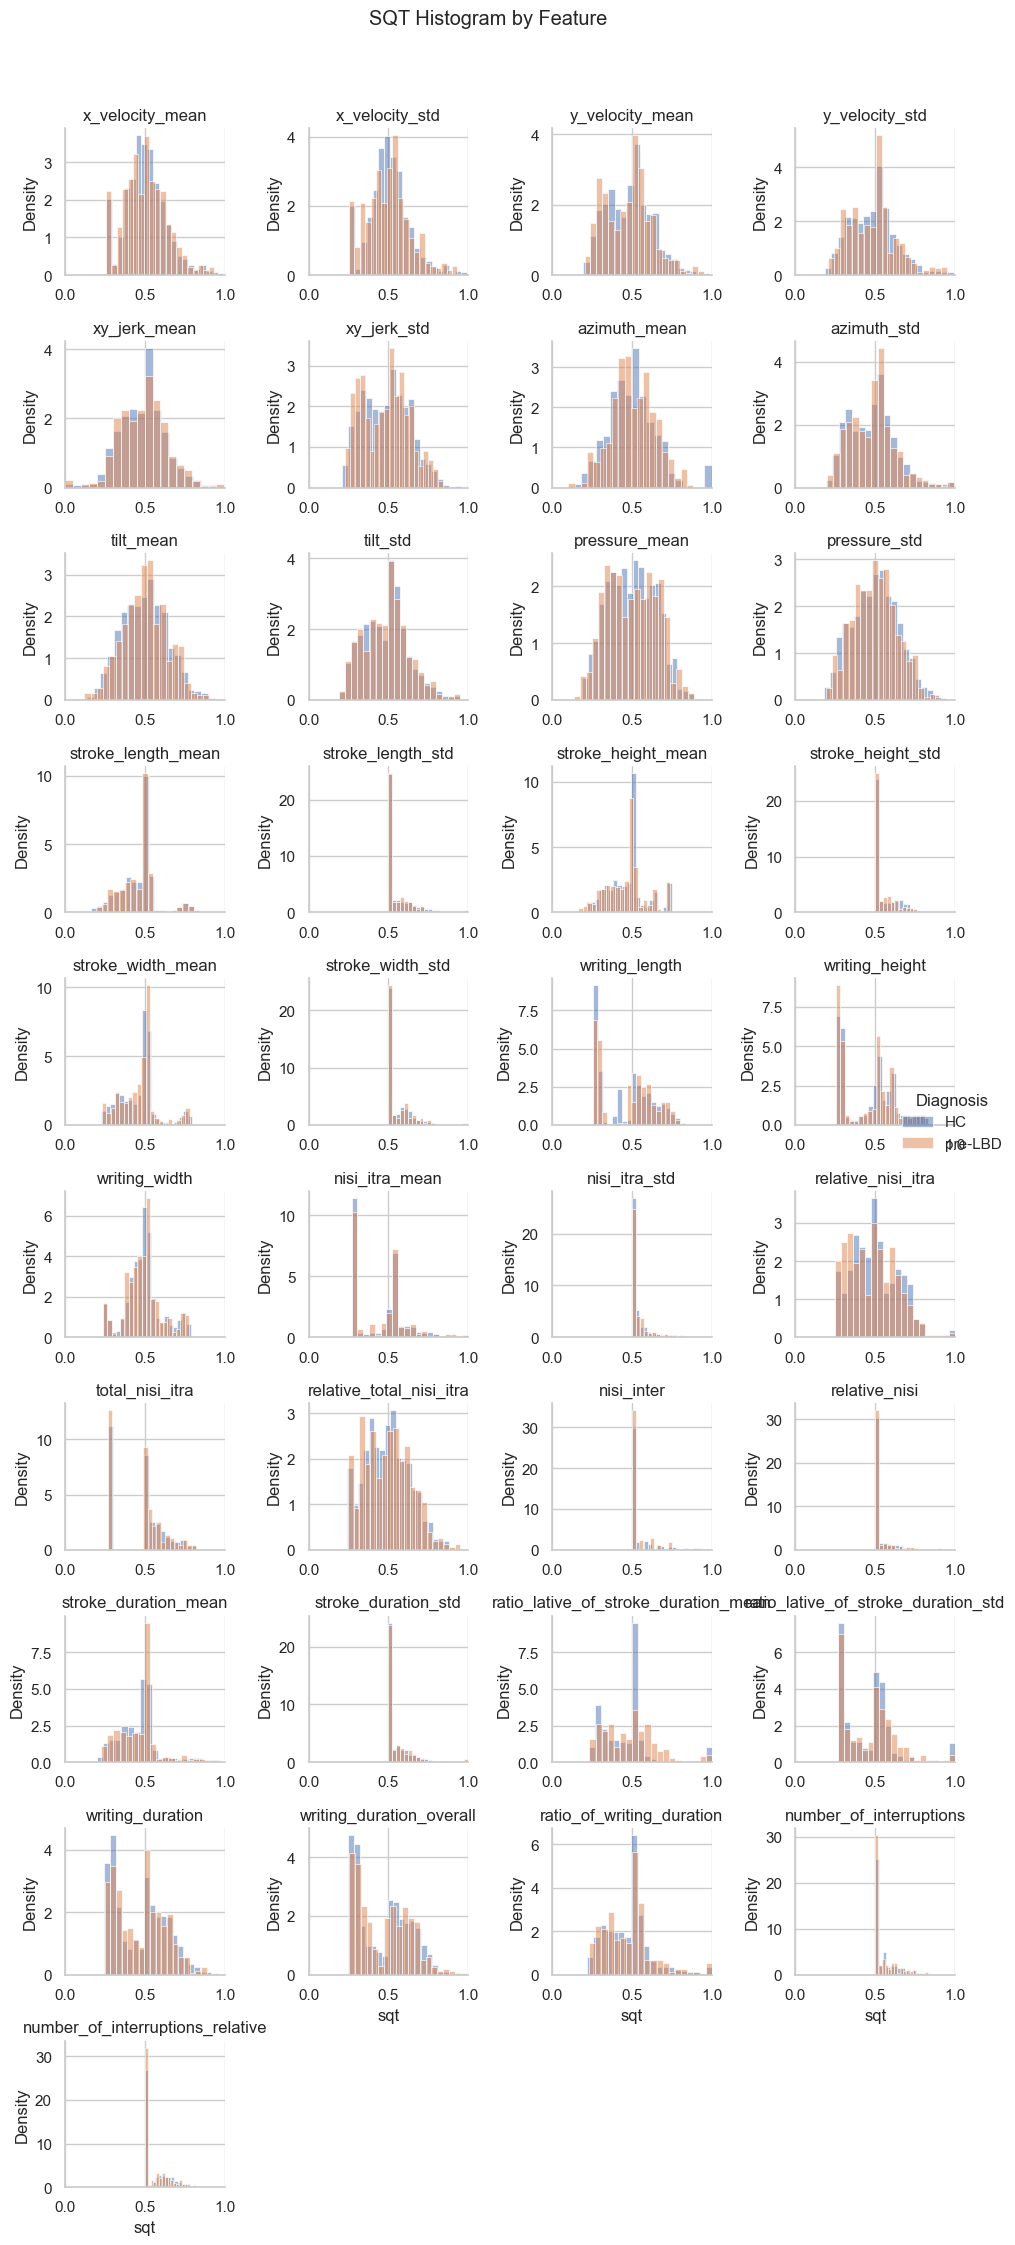

In [148]:
plot_sqt_histogram(sqt_long)

# Task-Wise analysis

## Task Split

In [ ]:
df["task"] = df["file_name"].str.extract(r"(\d+_\d+)").copy()
task_dfs = {task: g for task, g in df.groupby("task")}


## Mann-Whitney U test for all tasks -> Dictionary

In [ ]:
def statistical_analysis_per_task(task_dfs: dict):
    from scipy.stats import mannwhitneyu
    results = {}
    for task, task_df in task_dfs.items():
        features = [c for c in task_df.columns if c not in ("file_name", "diagnosis", "task")]
        task_results = pd.DataFrame(columns=["feature_name", "u_statistic", "p_value"])
        for feature in features:
            group_HC = task_df[task_df["diagnosis"] == 0][feature].dropna().values
            group_preLBD = task_df[task_df["diagnosis"] == 1][feature].dropna().values
            if len(group_HC) > 0 and len(group_preLBD) > 0:
                u_statistic, p_value = mannwhitneyu(group_HC, group_preLBD, alternative='two-sided')
                task_results = pd.concat([task_results, pd.DataFrame({"feature_name": [feature], "u_statistic": [u_statistic], "p_value": [p_value]})], ignore_index=True)
        results[task] = task_results
    return results

In [ ]:
result = statistical_analysis_per_task(task_dfs)

In [ ]:
print(result)

In [ ]:
def statistical_analysis_pipeline(df: pd.DataFrame):
    cleaned_df = convert_str_list_to_float(df).drop(columns=["task"], errors='ignore')

    mw_u_results = mw_u_test_whole_df(cleaned_df)
    p_value_filtered_df = p_value_filter(mw_u_results)
    plot_split_violin_plots(cleaned_df, col_wrap=3)
    sqt_long = sigmoid_quantile_test(cleaned_df, q=0.95)
    plot_sqt_kde(sqt_long)
    plot_sqt_histogram(sqt_long)

    return mw_u_results, p_value_filtered_df, sqt_long
    

In [ ]:
cleaned_df_10_1 = convert_str_list_to_float(task_dfs['10_1']).drop(columns=["task"], errors='ignore')

sqt_long_10_1 = sigmoid_quantile_test(cleaned_df_10_1, q=0.95)
plot_sqt_kde(sqt_long_10_1)

In [ ]:

cleaned_df = convert_str_list_to_float(task_dfs['19_1']).drop(columns=["task"], errors='ignore')

sqt_long = sigmoid_quantile_test(cleaned_df, q=0.95)
plot_sqt_kde(sqt_long)

# Task-wise plots

In [ ]:
mw_u_results_1_1, p_value_1_1, sqt_long_1_1 = statistical_analysis_pipeline(task_dfs['1_1'])

In [ ]:
mw_u_results_3_1, p_value_3_1, sqt_long_3_1 = statistical_analysis_pipeline(task_dfs['3_1'])
mw_u_results_3_2, p_value_3_2, sqt_long_3_2 = statistical_analysis_pipeline(task_dfs['3_2'])
mw_u_results_3_3, p_value_3_3, sqt_long_3_3 = statistical_analysis_pipeline(task_dfs['3_3'])
mw_u_results_3_4, p_value_3_4, sqt_long_3_4 = statistical_analysis_pipeline(task_dfs['3_4'])
mw_u_results_3_5, p_value_3_5, sqt_long_3_5 = statistical_analysis_pipeline(task_dfs['3_5'])
mw_u_results_9_1, p_value_9_1, sqt_long_9_1 = statistical_analysis_pipeline(task_dfs['9_1'])
mw_u_results_10_1, p_value_10_1, sqt_long_10_1 = statistical_analysis_pipeline(task_dfs['10_1'])
mw_u_results_15_1, p_value_15_1, sqt_long_15_1 = statistical_analysis_pipeline(task_dfs['15_1'])
mw_u_results_16_1, p_value_16_1, sqt_long_16_1 = statistical_analysis_pipeline(task_dfs['16_1'])
mw_u_results_17_1, p_value_17_1, sqt_long_17_1 = statistical_analysis_pipeline(task_dfs['17_1'])
mw_u_results_18_1, p_value_18_1, sqt_long_18_1 = statistical_analysis_pipeline(task_dfs['18_1'])
mw_u_results_19_1, p_value_19_1, sqt_long_19_1 = statistical_analysis_pipeline(task_dfs['19_1'])

In [ ]:
mw_u_results_3_2, p_value_3_2, sqt_long_3_2 = statistical_analysis_pipeline(task_dfs['19_1'])

In [ ]:
sqt_long_10_1

In [ ]:
cleaned_df_10_1 = convert_str_list_to_float(task_dfs['10_1']).drop(columns=["task"], errors='ignore')
cleaned_df_17_1 = convert_str_list_to_float(task_dfs['17_1']).drop(columns=["task"], errors='ignore')
cleaned_df_3_2 = convert_str_list_to_float(task_dfs['3_2']).drop(columns=["task"], errors='ignore')
cleaned_df_1_1 = convert_str_list_to_float(task_dfs['1_1']).drop(columns=["task"], errors='ignore')

sqt_long_10_1 = sigmoid_quantile_test(cleaned_df_10_1, q=0.95)
sqt_long_17_1 = sigmoid_quantile_test(cleaned_df_17_1, q=0.95)
sqt_long_3_2 = sigmoid_quantile_test(cleaned_df_3_2, q=0.95)
sqt_long_1_1 = sigmoid_quantile_test(cleaned_df_1_1, q=0.95)

In [ ]:
print(sqt_long_10_1)
print(sqt_long_17_1)
print(sqt_long_3_2)
print(sqt_long_1_1)

In [ ]:
#def plot_sqt_kde_from_long(sqt_long: pd.DataFrame):
    #import seaborn as sns
    #import matplotlib.pyplot as plt
#
    #hue_order = [0, 1]
    #base_pal = sns.color_palette(n_colors=2)
    #palette = {0: base_pal[0], 1: base_pal[1]}
#
    #sns.set(style="whitegrid")
    #g = sns.FacetGrid(
        #sqt_long, col="feature", hue="diagnosis", hue_order=hue_order,
        #palette=palette, sharex=False, sharey=False, col_wrap=4, height=2.2, aspect=1.0
    #)
    #g.map_dataframe(sns.kdeplot, x="sqt", fill=True, alpha=0.35, linewidth=1.0, common_norm=False)
#
    #for ax in g.axes.flat:
        #ax.set_title(ax.get_title().replace("feature = ", ""))
    #g.add_legend(title="Diagnosis")
    #g.fig.suptitle("SQT KDE by Feature (colors match violin plots)", y=1.02)
#
    #plt.tight_layout()
    #plt.show()


In [ ]:
def plot_sqt_kde_from_long(sqt_long):
    import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

    # Validate/clean
    need = {"feature", "diagnosis", "sqt"}
    if not need.issubset(sqt_long.columns):
        raise ValueError(f"Expected columns {need}, got {list(sqt_long.columns)}")

    df = sqt_long.copy()
    df["sqt"] = pd.to_numeric(df["sqt"], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["sqt"])

    # Order labels exactly as you use them
    labels = ["HC", "pre-LBD"] if {"HC","pre-LBD"}.issubset(set(df["diagnosis"])) \
             else list(pd.unique(df["diagnosis"]))
    df["diagnosis"] = pd.Categorical(df["diagnosis"], categories=labels, ordered=True)

    # If a (feature, diagnosis) group is constant or tiny, KDE draws nothing → keep but show rug
    grp = df.groupby(["feature","diagnosis"], group_keys=False)
    df_kde = grp.filter(lambda g: g["sqt"].nunique() > 1)

    sns.set(style="whitegrid")
    if df_kde.empty:
        # fallback to hist if KDE would be degenerate everywhere
        g = sns.FacetGrid(df, col="feature", hue="diagnosis", hue_order=labels,
                          sharex=False, sharey=False, col_wrap=4, height=2.2, aspect=1.0)
        g.map_dataframe(sns.histplot, x="sqt", stat="density", element="step", fill=False)
        title = "SQT distributions by Feature (hist fallback)"
    else:
        g = sns.FacetGrid(df_kde, col="feature", hue="diagnosis", hue_order=labels,
                          sharex=False, sharey=False, col_wrap=4, height=2.2, aspect=1.0)
        g.map_dataframe(sns.kdeplot, x="sqt", fill=True, alpha=0.35, linewidth=1.0, common_norm=False)
        # mark dropped constant groups with rugs so you still see them
        dropped = grp.filter(lambda g: g["sqt"].nunique() <= 1)
        if not dropped.empty:
            g.map_dataframe(sns.rugplot, x="sqt", height=0.05, linewidth=0.6, alpha=0.6)
        title = "SQT KDE by Feature"

    for ax in g.axes.flat:
        ax.set_title(ax.get_title().replace("feature = ", ""))
    g.add_legend(title="Diagnosis")
    g.fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


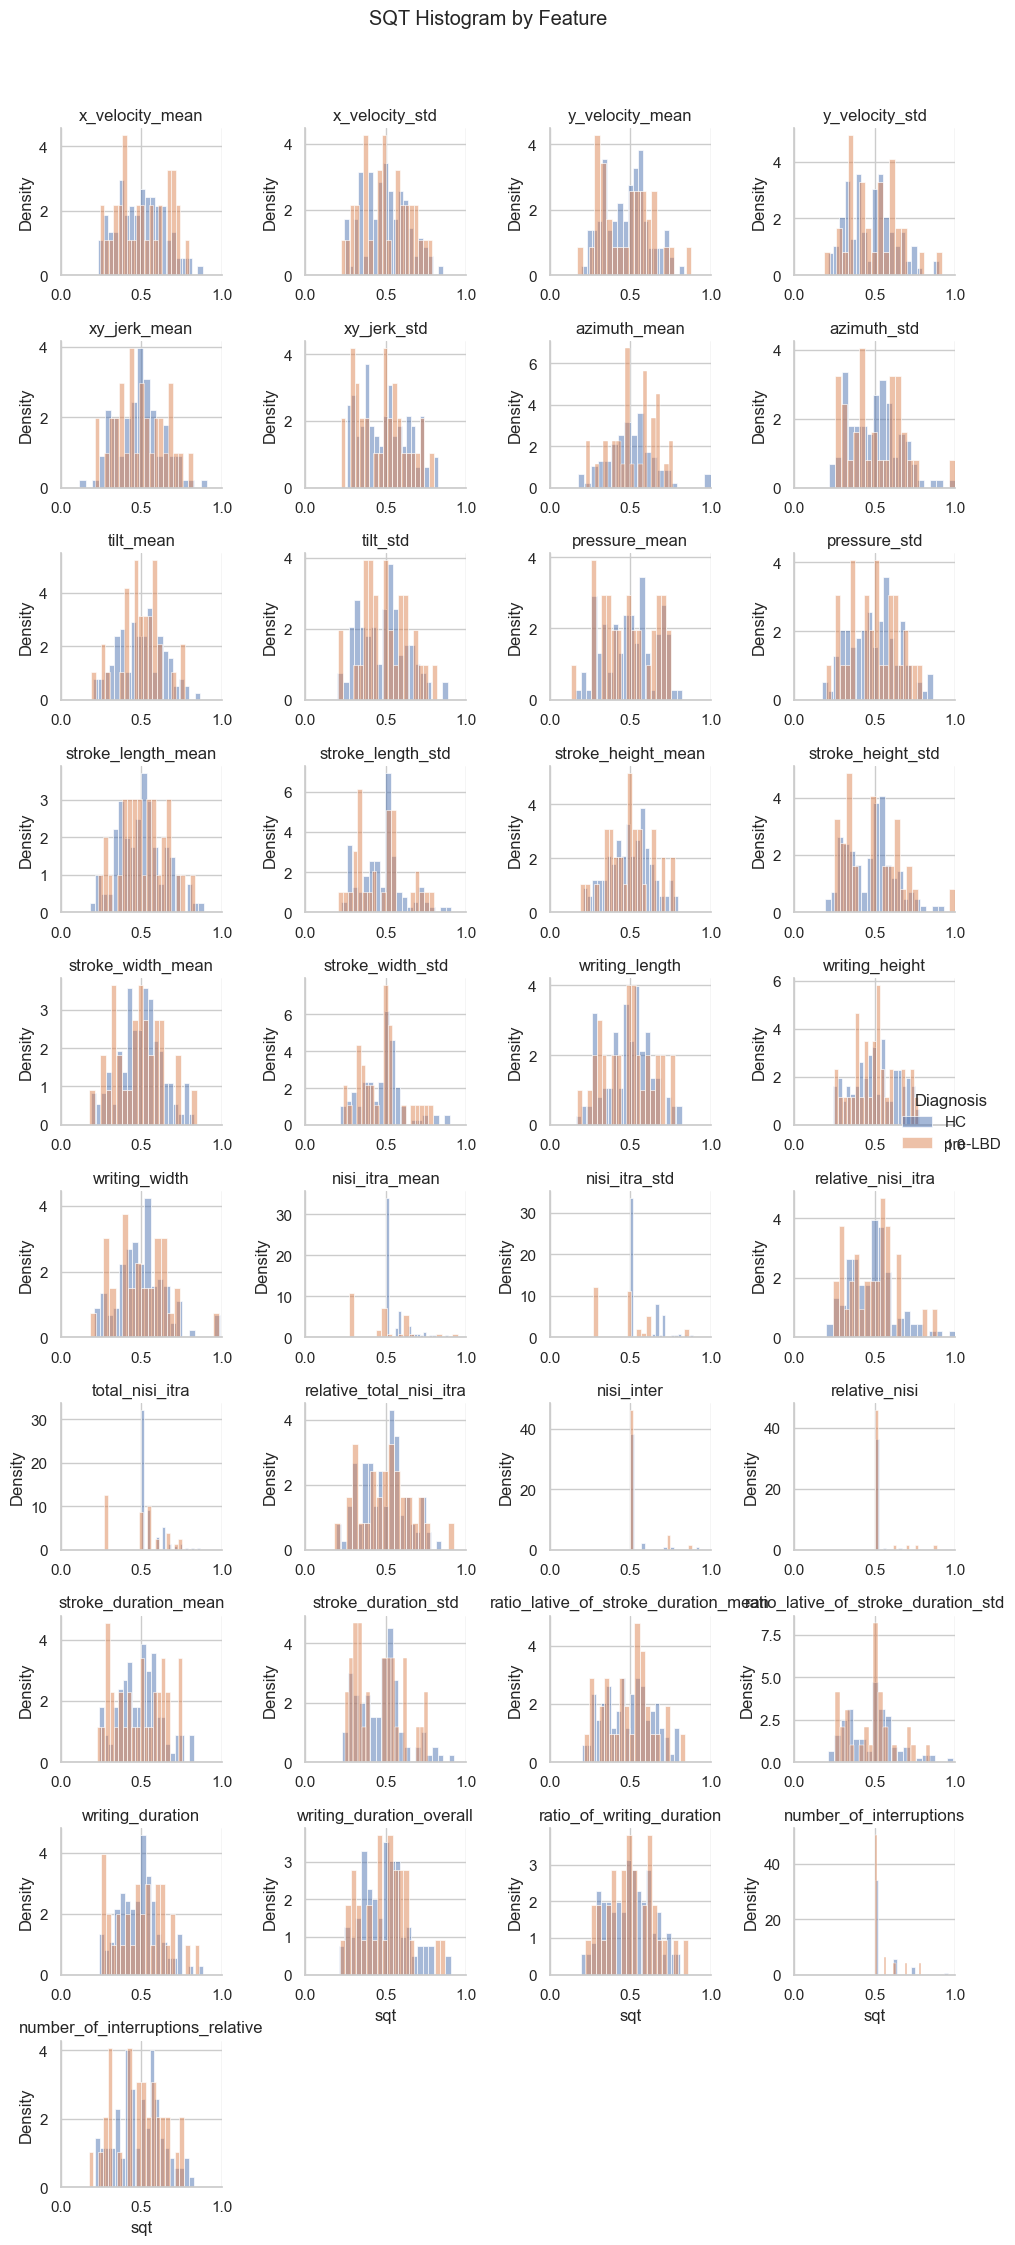

In [150]:
plot_sqt_histogram(sqt_long_10_1)

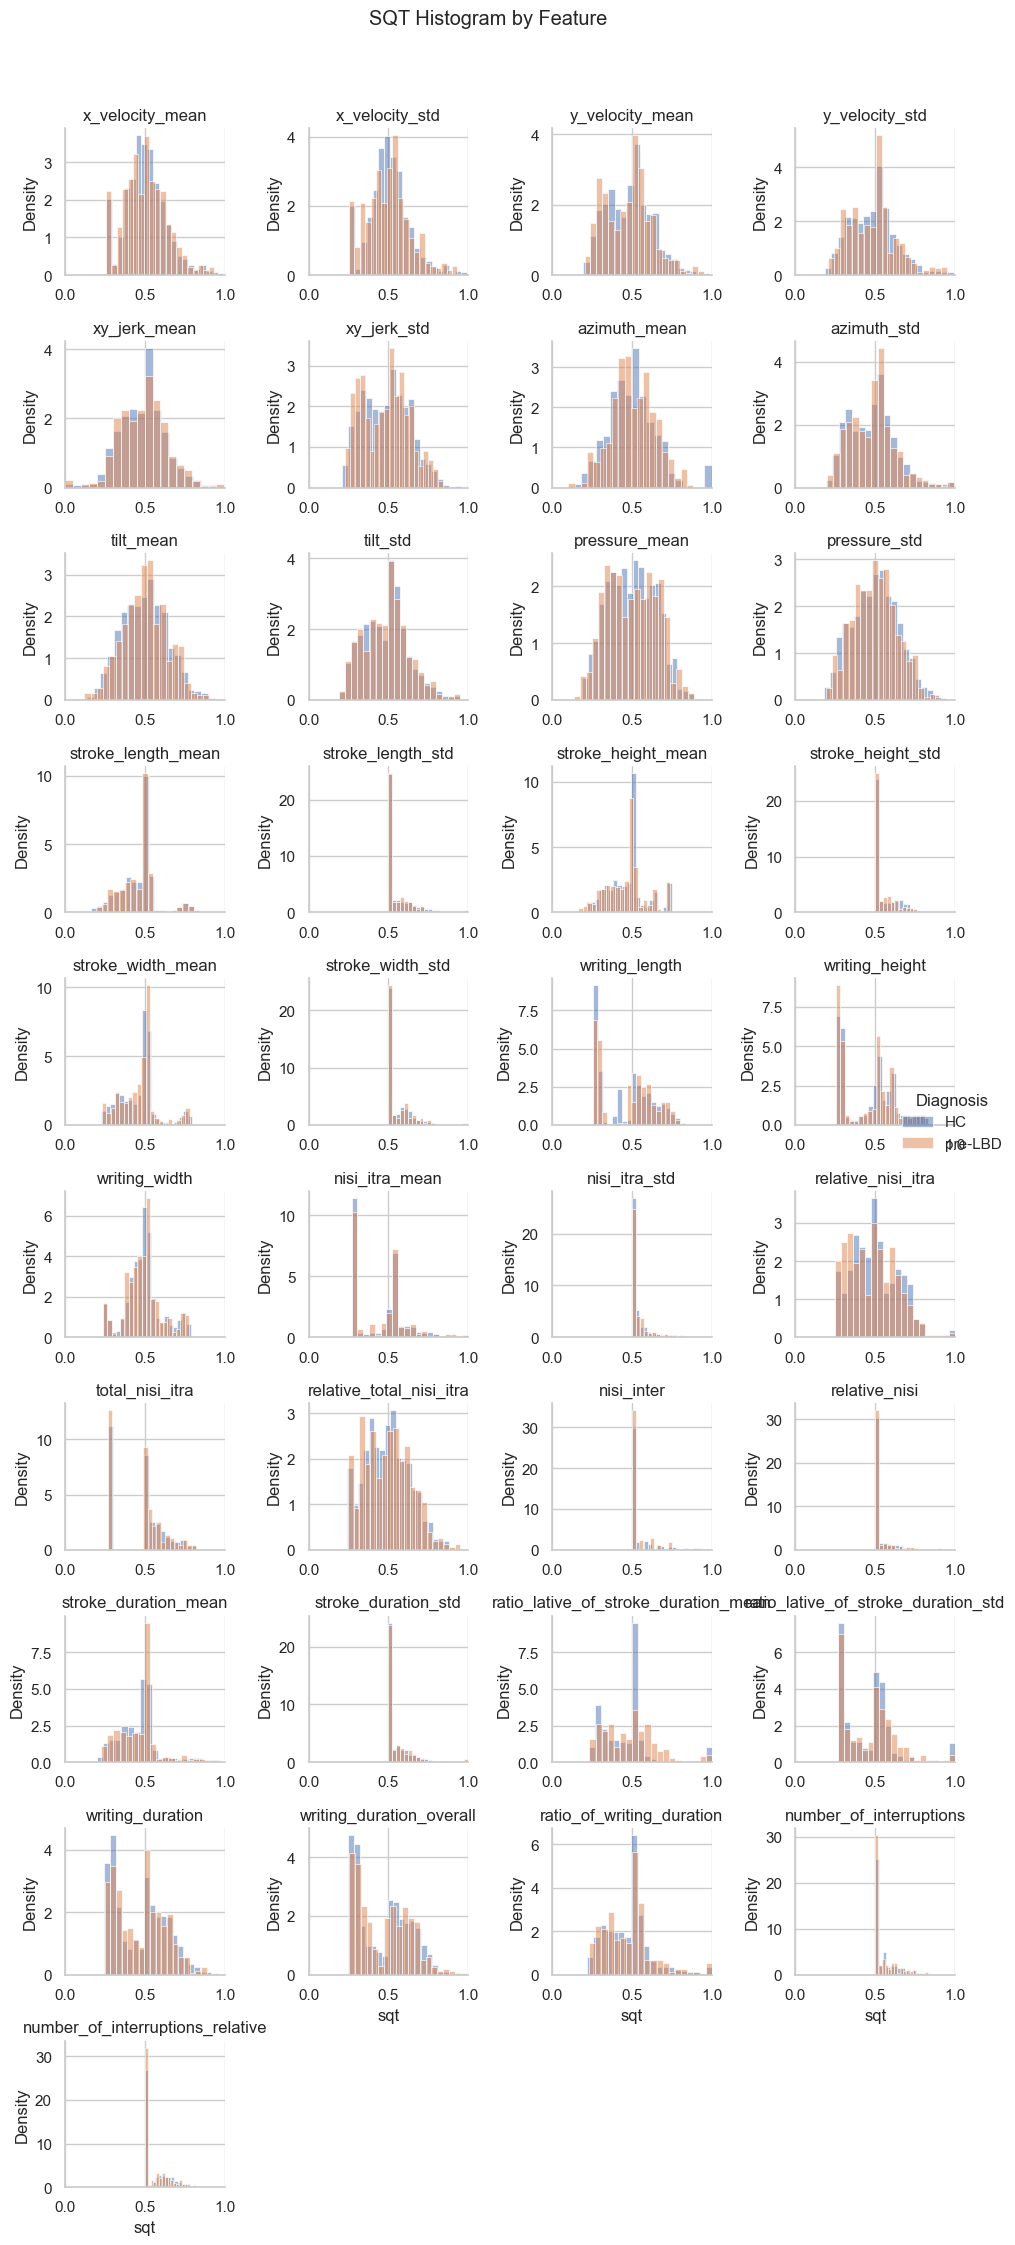

In [149]:
plot_sqt_histogram(sqt_long_19_1)

In [ ]:

plot_sqt_kde_from_long(sqt_long_1_1)